In [ ]:
import os, re
import pandas as pd

# This code aims to convert old formatted files into the train_samples.txt in dashboard to more efficiently manage the dataset.

def gen_list(src_name, tgt_name, write_to=True):
    tmp_data_path = f'/compute001/lwu/projects/GANomics_fullsource/trans_gan_project/run_datasets/{src_name}/trainAG'
    target_path = f'/compute001/lwu/projects/GANomics/dashboard/backend/results_ms/1_Training/checkpoints/{tgt_name}/train_samples.txt'
    if write_to is True:
        with open(target_path, 'w') as f:     
            for file in os.listdir(tmp_data_path):
                f.write(re.sub('.txt','',file)+'\n')
            print(src_name, 'Done.')
    else:
        for file in os.listdir(tmp_data_path):
            print(re.sub('.txt','',file))
    
    return

In [21]:
file_mapping = pd.read_csv('ms_mapping.txt',sep="\t",header=None)
file_mapping.columns=['tgt_name', 'src_name']
for ind, d in file_mapping.iterrows():
    gen_list(d['src_name'], d['tgt_name'], write_to=True)
    # if ind >3: break

datasets_BRCA1/tmp_10_0 Done.
datasets_BRCA1/tmp_100_0 Done.
datasets_BRCA1/tmp_150_0 Done.
datasets_BRCA1/tmp_20_0 Done.
datasets_BRCA1/tmp_50_0 Done.
datasets_BRCA2/tmp_10_0 Done.
datasets_BRCA2/tmp_100_0 Done.
datasets_BRCA2/tmp_50_0 Done.
datasets_NB_noFB/tmp_50_0 Done.
datasets_NB_noFB/tmp_50_1 Done.
datasets_NB_noFB/tmp_50_2 Done.
datasets_NB_noFB/tmp_50_3 Done.
datasets_NB_noFB/tmp_50_4 Done.
datasets_LAML1/tmp_50_0 Done.
datasets_LUSC1/tmp_50_0 Done.
datasets_METSIM/tmp_10_0 Done.
datasets_METSIM/tmp_100_0 Done.
datasets_METSIM/tmp_20_0 Done.
datasets_METSIM/tmp_50_0 Done.
datasets_NB/tmp_10_0 Done.
datasets_NB/tmp_10_1 Done.
datasets_NB/tmp_10_2 Done.
datasets_NB/tmp_10_3 Done.
datasets_NB/tmp_10_4 Done.
datasets_NB/tmp_20_0 Done.
datasets_NB/tmp_20_1 Done.
datasets_NB/tmp_20_2 Done.
datasets_NB/tmp_20_3 Done.
datasets_NB/tmp_20_4 Done.
datasets_NB/tmp_30_0 Done.
datasets_NB/tmp_30_1 Done.
datasets_NB/tmp_30_2 Done.
datasets_NB/tmp_30_3 Done.
datasets_NB/tmp_30_4 Done.
dataset

Pearson | Microarray: t = 8.3451, p=0.001
Pearson | RNAseq: t = 6.5810, p=0.003
Spearman | Microarray: t = 9.0035, p<0.001
Spearman | RNAseq: t = 6.5855, p=0.003
L1 | Microarray: t = -2.8050, p=0.048
L1 | RNAseq: t = -4.9170, p=0.008


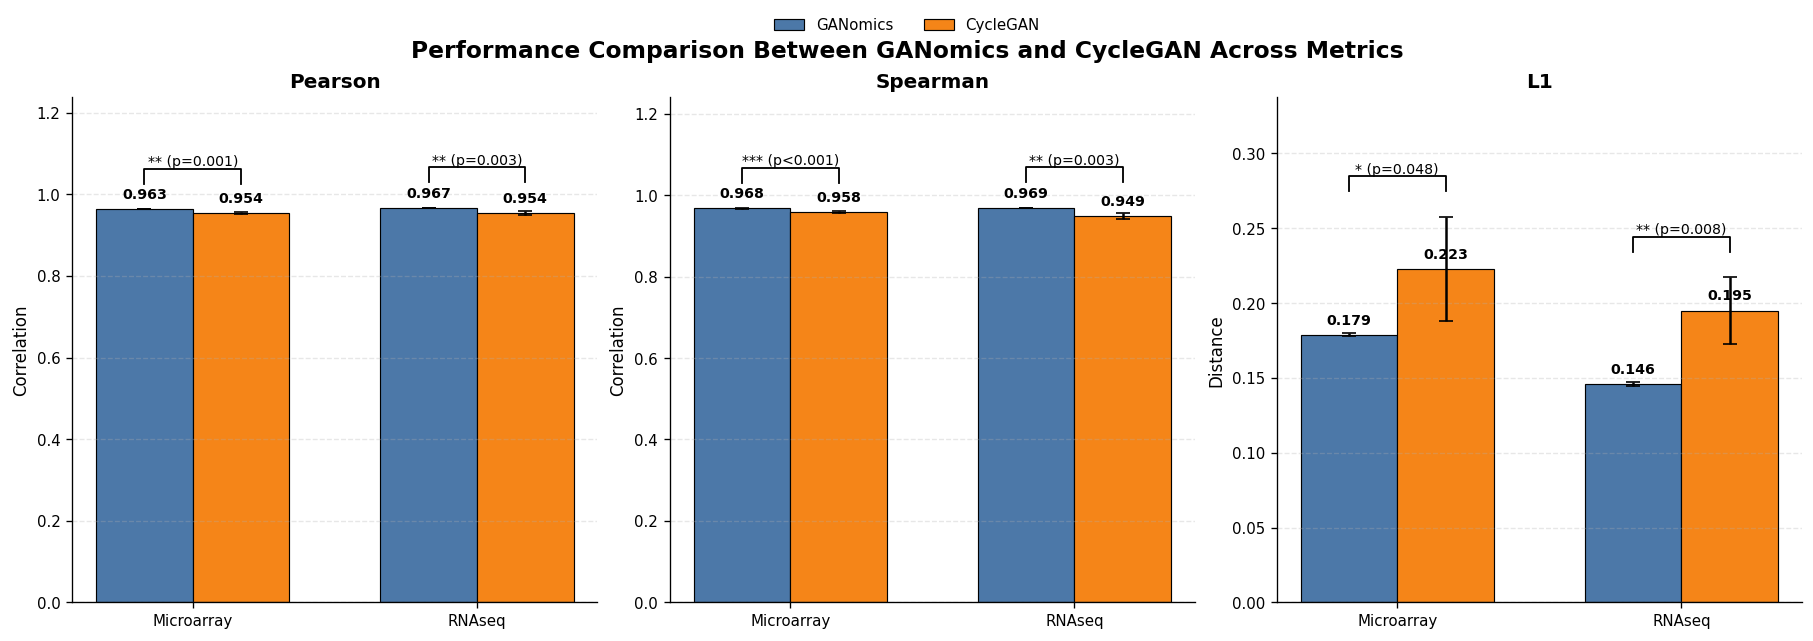

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================
# Configuration
# =========================
FILE_PATH = "../Alignment_result_ms.xlsx"
METHOD_PATTERNS = {
    "GANomics": "run",
    "CycleGAN": "CycleGAN"
}
PLATFORMS = ["Microarray", "RNAseq"]
METRICS = ["Pearson", "Spearman", "L1"]

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =========================
# Helper functions
# =========================
def significance_label(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"


def format_p_value(p):
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"


def get_series(df, task_pattern, platform, metric):
    return df[
        df["Task"].str.contains(task_pattern, case=False, na=False) &
        (df["Platform"] == platform)
    ][metric].dropna()


def welch_ttest(x, y):
    return ttest_ind(x, y, equal_var=False, nan_policy="omit")


def add_value_labels(ax, bars, values, y_offset_ratio=0.015):
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * y_offset_ratio
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold"
        )


def add_sig_bracket(ax, x1, x2, y, h, p_val, fontsize=8.5):
    text = f"{significance_label(p_val)} ({format_p_value(p_val)})"
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.1, c="black")
    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=fontsize
    )


# =========================
# Load data
# =========================
df = pd.read_excel(FILE_PATH)

# =========================
# Prepare summary stats
# =========================
summary = []

for metric in METRICS:
    for platform in PLATFORMS:
        g1 = get_series(df, METHOD_PATTERNS["GANomics"], platform, metric)
        g2 = get_series(df, METHOD_PATTERNS["CycleGAN"], platform, metric)

        t_stat, p_val = welch_ttest(g1, g2)

        summary.append({
            "Metric": metric,
            "Platform": platform,
            "GANomics_mean": g1.mean(),
            "GANomics_std": g1.std(),
            "CycleGAN_mean": g2.mean(),
            "CycleGAN_std": g2.std(),
            "p_value": p_val,
            "t_stat": t_stat
        })

summary_df = pd.DataFrame(summary)

# Print stats
for _, row in summary_df.iterrows():
    print(
        f"{row['Metric']} | {row['Platform']}: "
        f"t = {row['t_stat']:.4f}, {format_p_value(row['p_value'])}"
    )

# =========================
# Plot
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

colors = {
    "GANomics": "#4C78A8",
    "CycleGAN": "#F58518"
}

x = np.arange(len(PLATFORMS))   # [0, 1]
width = 0.34

for ax, metric in zip(axes, METRICS):
    data_m = summary_df[summary_df["Metric"] == metric].set_index("Platform").loc[PLATFORMS]

    gan_means = data_m["GANomics_mean"].values
    cyc_means = data_m["CycleGAN_mean"].values
    gan_stds = data_m["GANomics_std"].values
    cyc_stds = data_m["CycleGAN_std"].values
    p_vals = data_m["p_value"].values

    bars1 = ax.bar(
        x - width / 2,
        gan_means,
        width,
        yerr=gan_stds,
        capsize=4,
        label="GANomics",
        color=colors["GANomics"],
        edgecolor="black",
        linewidth=0.7
    )

    bars2 = ax.bar(
        x + width / 2,
        cyc_means,
        width,
        yerr=cyc_stds,
        capsize=4,
        label="CycleGAN",
        color=colors["CycleGAN"],
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(PLATFORMS)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    if metric in ["Pearson", "Spearman"]:
        ax.set_ylabel("Correlation")
    else:
        ax.set_ylabel("Distance")

    # Set y-limits with room for labels and p-values
    bar_tops = np.maximum(gan_means + gan_stds, cyc_means + cyc_stds)
    y_min = min(0, np.nanmin([gan_means - gan_stds, cyc_means - cyc_stds]))
    y_max = np.nanmax(bar_tops)

    # More headroom for annotations
    pad = max((y_max - y_min) * 0.28, 0.08 if y_max <= 1 else 0.15)
    ax.set_ylim(y_min, y_max + pad)

    # Add value labels
    add_value_labels(ax, bars1, gan_means)
    add_value_labels(ax, bars2, cyc_means)

    # Add significance bracket for each platform pair
    for i in range(len(x)):
        left_bar_x = x[i] - width / 2
        right_bar_x = x[i] + width / 2
        pair_top = max(gan_means[i] + gan_stds[i], cyc_means[i] + cyc_stds[i])

        h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03
        y = pair_top + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05

        add_sig_bracket(
            ax,
            left_bar_x,
            right_bar_x,
            y,
            h,
            p_vals[i]
        )

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))

fig.suptitle(
    "Performance Comparison Between GANomics and CycleGAN Across Metrics",
    fontsize=14,
    fontweight="bold"
)

plt.show()